# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### 선형회귀 실습

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 데이터 불러오기
housing = fetch_california_housing()
print(housing.DESCR) # 데이터에 대한 설명 출력

# 데이터 프레임 만들기 (독립변수 X)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 종속변수 Series 만들기 (y)
y = pd.Series(housing.target, name="MedHouseValue")


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
# 교안처럼 전체 데이터를 한눈에 보기 위해 X와 y를 합친 data 생성
data = pd.concat([X, y], axis=1)
data.head()

NameError: name 'data' is not defined

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

print("학습 데이터 크기 : ", X_train.shape)
print("시험 데이터 크기 : ", X_test.shape)

학습 데이터 크기 :  (16512, 8)
시험 데이터 크기 :  (4128, 8)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [8]:
comparison = pd.DataFrame({'actual' : y_test, 'pred' : pred})
display(comparison.head(10))

,actual,pred
8151,2.453,2.076538
53,1.042,1.579768
3039,1.462,2.087317
9484,1.542,1.594133
9307,3.242,2.043881
7471,1.411,1.876028
6823,2.273,2.628049
13359,2.023,2.299709
19408,1.702,1.101024
20249,3.018,2.965872


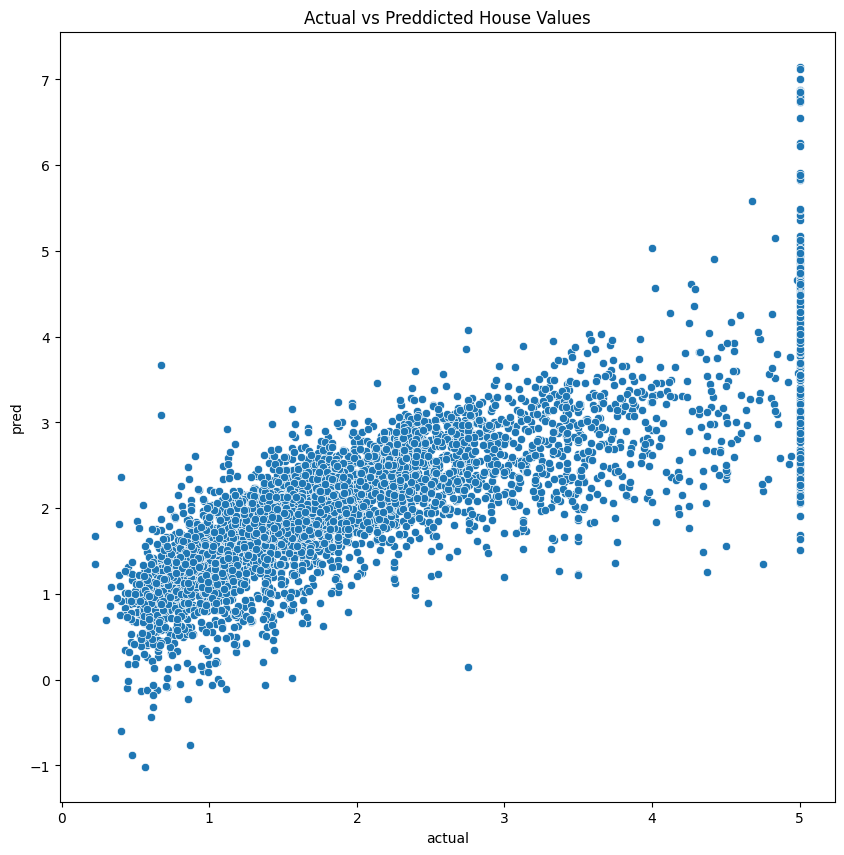

In [9]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x = 'actual', y = 'pred', data = comparison)
plt.title("Actual vs Preddicted House Values")
plt.show()

In [10]:
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"RMSE (루트 평균 제곱 오차) : {rmse:.4f}")
print(f"MAE (평균 절대 오차) : {mae:.4f}")
print(f"R2 Score (결정 계수) : {r2:.4f}")

RMSE (루트 평균 제곱 오차) : 0.7134
MAE (평균 절대 오차) : 0.5278
R2 Score (결정 계수) : 0.6223


In [11]:
coef_series = pd.Series(model.coef_, index = X.columns)
print("=== 각 독립변수의 기울기(계수) ===")
print(coef_series)

print('\n=== y절편 ===')
print(model.intercept_)

=== 각 독립변수의 기울기(계수) ===
MedInc        0.433433
HouseAge      0.009226
AveRooms     -0.106548
AveBedrms     0.646494
Population   -0.000007
AveOccup     -0.003459
Latitude     -0.423282
Longitude    -0.437466
dtype: float64

=== y절편 ===
-37.20562128878817
